# AIAP Foundation - Classification

## Objective 

To develop machine learning models that can accurately **classify HDB resale flats as either above or below the median price**. This binary classification task will help potential buyers and sellers quickly understand the relative value of a flat in the resale market.

## Data Dictionary

| Field               | Description.                                          |
| ------------------- | ----------------------------------------------------- |
| id                  | Unique identification number                          |
| month               | Year and month that registered the resale price       |
| flat_type           | Number of bedrooms the resale flat has                |
| block               | Block number of the resale flat                       |
| street_name         | Street name where the resale flat is located          |
| storey_range        | Floor level (range) of the resale flat                |
| floor_area_sqm      | Floor area of the resale flat in square meters        |     
| lease_commence_date | Commencement year of the flat unit's 99-year lease    |
| remaining_lease.    | Remaining years until the resale flat expires         |
| price_category      | Whether the resale flat's price is above (1) or below (0) the median price  |
| town_id             | Number identification of the HDB town where the resale flat is located      |
| flatm_id            | Number identification of the HDB design model of the resale flat            |
| town_name           | HDB town where the resale flat is located             |
| flatm_name          | HDB design model of the resale flat                   |

<br>
<hr>

## Exploratory Data Analysis

In [1]:
# Load Python Standard Libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings


# Load Third Party Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pprint

In [2]:
# Assign Global Variables
PLOT_PATH = './images/'
FILE_PATH = './data/resale_transactions_categorised.csv'

# Set Jupyter Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 999)

In [3]:
# Load the dataset: first check the file exists and stop execution with a clear message if not.
file_path_obj = Path(FILE_PATH)
if not file_path_obj.is_file():
    print(f"File not found at: {FILE_PATH}")
    # print("Please check the FILE_PATH variable or place the CSV at the expected location.")
    print("Exiting program.")
    sys.exit(1)
# If the file exists, read it into a DataFrame and show the dataset's dimensions.
df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows by {df.shape[1]:,} columns.")

Dataset loaded: 88,688 rows by 14 columns.


In [4]:
# Look at Dataset
display(df.head(10))

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,town_id,flatm_id,town_name,flatm_name,price_category
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,17,5,PASIR RIS,Improved,Above Median
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,21,8,SENGKANG,Model A,Below Median
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,9,5,CHOA CHU KANG,Improved,Below Median
3,4,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,12,8,HOUGANG,Model A,Above Median
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,22,5,SERANGOON,Improved,Above Median
5,6,2018-09,4 ROOM,503,ANG MO KIO AVE 5,04 TO 06,93.0,1981,61 years 04 months,1,12,ANG MO KIO,New Generation,Above Median
6,7,2017-07,5 ROOM,264,BISHAN ST 24,13 TO 15,134.0,1992,74 years 01 month,3,8,BISHAN,Model A,Above Median
7,8,2017-09,5 ROOM,602,BEDOK RESERVOIR RD,07 TO 09,121.0,1982,63 years 08 months,2,5,BEDOK,Improved,Above Median
8,9,2017-10,3 ROOM,20,ST. GEORGE'S RD,04 TO 06,82.0,1984,66 years,15,12,KALLANG/WHAMPOA,New Generation,Above Median
9,10,2016-01,5 ROOM,311B,ANCHORVALE LANE,13 TO 15,111.0,2002,85,21,13,SENGKANG,Premium Apartment,Above Median


In [5]:
# Checking Dataset's Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   88688 non-null  int64  
 1   month                88688 non-null  object 
 2   flat_type            88688 non-null  object 
 3   block                88688 non-null  object 
 4   street_name          88688 non-null  object 
 5   storey_range         88688 non-null  object 
 6   floor_area_sqm       88688 non-null  float64
 7   lease_commence_date  88688 non-null  int64  
 8   remaining_lease      88688 non-null  object 
 9   town_id              88688 non-null  int64  
 10  flatm_id             88688 non-null  int64  
 11  town_name            87905 non-null  object 
 12  flatm_name           88174 non-null  object 
 13  price_category       88688 non-null  object 
dtypes: float64(1), int64(4), object(9)
memory usage: 9.5+ MB


In [6]:
# Checking for missing values
# Identify columns with missing data
missing_counts = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

# Filter columns with missing values
missing_columns = missing_counts[missing_counts > 0].index.tolist()

# Display columns with missing values, their count, and percentage
print("Columns with missing data:\n")
for col in missing_columns:
    print(f"{col:<25} : {missing_counts[col]:>6,} missing ({missing_percent[col]:>5.2f}%)")

Columns with missing data:

town_name                 :    783 missing ( 0.88%)
flatm_name                :    514 missing ( 0.58%)


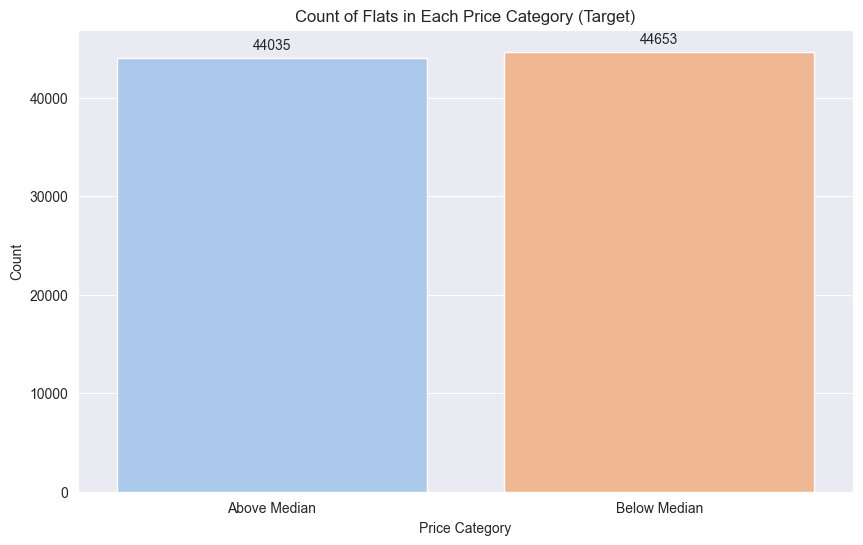

In [7]:
# Set the aesthetic style of the plots
sns.set_style("darkgrid")

# Bar chart for price category with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='price_category', data=df, palette='pastel')
plt.title('Count of Flats in Each Price Category (Target)')
plt.xlabel('Price Category')
plt.ylabel('Count')
#plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

### Preparing the Target Variable

In [8]:
# Encode the target column
df['price_category'] = df['price_category'].map({'Above Median': 1, 'Below Median': 0})

# Check the distribution of the target column
df['price_category'].value_counts()

price_category
0    44653
1    44035
Name: count, dtype: int64

## Data Cleaning and Preprocessing

### Correcting Structural Errors 

In [9]:
# Absolute negative years values
df['lease_commence_date'] = df['lease_commence_date'].abs()

In [ ]:
# Replace 'FOUR ROOM' with '4 ROOM' in the 'flat_type' column
df['flat_type'] = df['flat_type'].replace('FOUR ROOM', '4 ROOM')

### Handling Missing Values

In [10]:
def fill_missing_names(df: pd.DataFrame, id_column: str, name_column: str) -> pd.DataFrame:
    """
    Fills missing values in the 'name_column' using the 'id_column'.

    Args:
        df (pd.DataFrame): The DataFrame containing the columns to be filled.
        id_column (str): The name of the column containing the IDs.
        name_column (str): The name of the column containing the names to be filled.

    Returns:
        pd.DataFrame: The DataFrame with missing valuebbbbbs in 'name_column' filled.
    """
    # Identify missing values in the 'name_column'
    missing_names = df[name_column].isna()

    # Create a dictionary mapping 'id_column' to 'name_column'
    name_mapping = df[[id_column, name_column]].dropna().drop_duplicates().set_index(id_column)[name_column].to_dict()

    # Fill missing 'name_column' using the mapping
    df.loc[missing_names, name_column] = df.loc[missing_names, id_column].map(name_mapping)

    return df

In [11]:
# Fill missing values in 'town_name' column
df = fill_missing_names(df=df, id_column='town_id', name_column='town_name')

# Fill missing values in 'flatm_name' column
df = fill_missing_names(df=df, id_column='flatm_id', name_column='flatm_name')

### Removing Unncessary Data

In [12]:
# Removing duplicates
df.drop_duplicates(inplace = True)

In [13]:
# Drop irrelevant features
df = df.drop(columns = ['id', 'town_id', 'flatm_id'])
             

In [14]:
df.head(5)

,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,town_name,flatm_name,price_category
0,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,PASIR RIS,Improved,1
1,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,SENGKANG,Model A,0
2,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,CHOA CHU KANG,Improved,0
3,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,HOUGANG,Model A,1
4,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,SERANGOON,Improved,1


## Feature Engineering

Feature Engineering - `month`

In [15]:
# Convert 'month' to datetime
df['year_month'] = pd.to_datetime(df['month'], format = '%Y-%m')

# Extract year and month from the datetime object
df['year'] = df['year_month'].dt.year
df['month'] = df['year_month'].dt.month

df.head()

,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,town_name,flatm_name,price_category,year_month,year
0,5,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,PASIR RIS,Improved,1,2018-05-01,2018
1,10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,SENGKANG,Model A,0,2016-10-01,2016
2,10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,CHOA CHU KANG,Improved,0,2018-10-01,2018
3,12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,HOUGANG,Model A,1,2015-12-01,2015
4,9,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,SERANGOON,Improved,1,2017-09-01,2017


In [16]:
# Drop year-month
df = df.drop(columns = ['year_month'])

### Feature Engineering - `remaining_lease_months`

In [17]:
import re

def extract_lease_info(lease_str: str) -> int:
    """
    Convert lease information from a string format to total months.

    This function takes a string representing the remaining lease period, which
    may include years and months in various formats (e.g., "70 years 3 months",
    "85 years", "67"), and converts it to the total number of months.

    Args:
        lease_str (str): The remaining lease period as a string.

    Returns:
        int: The total number of months, or None if the input is NaN.
    """

    if pd.isna(lease_str):
        return None
    
    # Regular expression to extract years and months
    years_match = re.search(r'(\d+)\s*years?', lease_str)
    months_match = re.search(r'(\d+)\s*months?', lease_str)
    number_match = re.match(r'^\d+$', lease_str.strip())
    
    if years_match:
        years = int(years_match.group(1))
    elif number_match:  # If only a number is present, assume it's in years
        years = int(number_match.group(0))
    else:
        years = 0
        
    months = int(months_match.group(1)) if months_match else 0
    
    # Convert the total lease period to months
    total_months = years * 12 + months
    return total_months

In [18]:
# Extract lease information
df['remaining_lease_months'] = df['remaining_lease'].apply(extract_lease_info) 
# Display a random sample of the data to check the transformation
df[['remaining_lease', 'remaining_lease_months']].sample(5)

,remaining_lease,remaining_lease_months
39151,71 years 07 months,859
51138,62 years,744
83861,70 years 11 months,851
35110,68,816
56293,65 years 10 months,790


In [19]:
# Drop the 'remaining_lease' column
df = df.drop(columns=['remaining_lease'])

### Feature Engineering - `storey_range`

In [20]:
# Function to convert storey_range to ordinal scale by taking the average of the range
def convert_storey_range(storey_range: str) -> float:
    """
    Converts a storey range string into its average numerical value.
    
    The function takes a storey range in the format 'XX TO YY', splits it into two parts,
    converts these parts to integers, and returns the average of these integers.
    
    Args:
        storey_range (str): A string representing a range of storeys, in the format 'XX TO YY'.
        
    Returns:
        float: The average value of the two storeys in the range.
        
    Example:
        convert_storey_range('07 TO 09') -> 8.0
    """
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

In [21]:
# Use the .apply() method to convert the 'storey_range' column with the function
df['storey_range'] = df['storey_range'].apply(convert_storey_range)

### Advanced Feature Engineering

In [23]:
# Drop the 'block' and 'street_name' columns
df = df.drop(columns = ['block', 'street_name'])

In [24]:
df.head(10)

,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,town_name,flatm_name,price_category,year,remaining_lease_months
0,5,5 ROOM,8.0,123.0,1989,PASIR RIS,Improved,1,2018,843
1,10,4 ROOM,2.0,100.0,1999,SENGKANG,Model A,0,2016,972
2,10,5 ROOM,20.0,110.0,2002,CHOA CHU KANG,Improved,0,2018,990
3,12,4 ROOM,14.0,103.0,1984,HOUGANG,Model A,1,2015,804
4,9,5 ROOM,8.0,122.0,1992,SERANGOON,Improved,1,2017,890
5,9,4 ROOM,5.0,93.0,1981,ANG MO KIO,New Generation,1,2018,736
6,7,5 ROOM,14.0,134.0,1992,BISHAN,Model A,1,2017,889
7,9,5 ROOM,8.0,121.0,1982,BEDOK,Improved,1,2017,764
8,10,3 ROOM,5.0,82.0,1984,KALLANG/WHAMPOA,New Generation,1,2017,792
9,1,5 ROOM,14.0,111.0,2002,SENGKANG,Premium Apartment,1,2016,1020


### Feature-Target Separation

In [ ]:
# Separate the data into features and target
X = df.drop(columns='price_category')
y = df['price_category']

### Train-Validation-Testing Separatrion

In [26]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [27]:
# Display the shapes of the splits to verify
print('Training set shape:\t', X_train.shape, y_train.shape)
print('Validation set shape:\t', X_val.shape, y_val.shape)
print('Test set shape:\t\t', X_test.shape, y_test.shape)

Training set shape:	 (67572, 9) (67572,)
Validation set shape:	 (8446, 9) (8446,)
Test set shape:		 (8447, 9) (8447,)


In [28]:
df.columns

Index(['month', 'flat_type', 'storey_range', 'floor_area_sqm',
       'lease_commence_date', 'town_name', 'flatm_name', 'price_category',
       'year', 'remaining_lease_months'],
      dtype='object')

## Building a Pipeline

### Implementing Standardization

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define numerical features to be standardized
numerical_features = ['floor_area_sqm', 'remaining_lease_months', 'lease_commence_date', 'year']

# Create a numerical transformer pipeline
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

### Implementing Feature Encoding

In [30]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Define nomial features to be one-hot encoded
nominal_features = ['month', 'town_name', 'flatm_name']

# Define ordinal features to be ordinally encoded
ordinal_features = ['flat_type']

# Define the ordinal categories for flat_type
flat_type_categories = ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'MULTI-GENERATION', 'EXECUTIVE']

# Define passthrough features that will not be transformed
passthrough_features = ['storey_range']

# Create a nominal transformer pipeline
nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create an ordinal transformer pipeline
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[flat_type_categories], handle_unknown='use_encoded_value', unknown_value=-1))
])

### Combined Feature Scaling and Encoding

In [31]:
from sklearn.compose import ColumnTransformer

# Combine transformers into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('pass', 'passthrough', passthrough_features) # Pass through the storey_range feature without transformation
    ],
    remainder='passthrough',
    n_jobs=-1
    )

In [32]:
preprocessor

,transformers,"[('num', ...), ('nom', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Model Development

### Implementing Multivariate Logistic Regression

In [33]:
# Import the necessary library
from sklearn.linear_model import LogisticRegression

# Create the pipeline with a logistic regression model
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Use the preprocessor pipeline defined earlier
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the pipeline to the training data
logreg_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = logreg_pipeline.predict(X_val)

In [34]:
logreg_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nom', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Model Evaluation

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the classification metrics for Logistic Regression
logreg_val_accuracy = accuracy_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Accuracy: {logreg_val_accuracy:.5f}')

Logistic Regression Metrics:
LogReg Validation Accuracy: 0.89238


### Confusion Matrix

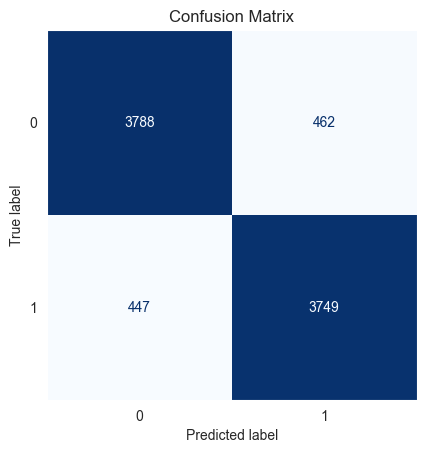

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots()
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

### Precision, Recall and F1 Score

In [37]:
# Calculate the classification metrics for Logistic Regression
logreg_val_precision = precision_score(y_val, y_val_pred)
logreg_val_recall = recall_score(y_val, y_val_pred)
logreg_val_f1 = f1_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Precision: {logreg_val_precision:.5f}')
print(f'LogReg Validation Recall: {logreg_val_recall:.5f}')
print(f'LogReg Validation F1 Score: {logreg_val_f1:.5f}')

Logistic Regression Metrics:
LogReg Validation Precision: 0.89029
LogReg Validation Recall: 0.89347
LogReg Validation F1 Score: 0.89188


### Receiver Operator Characteristic (ROC) and Area Under Curve (AUC)

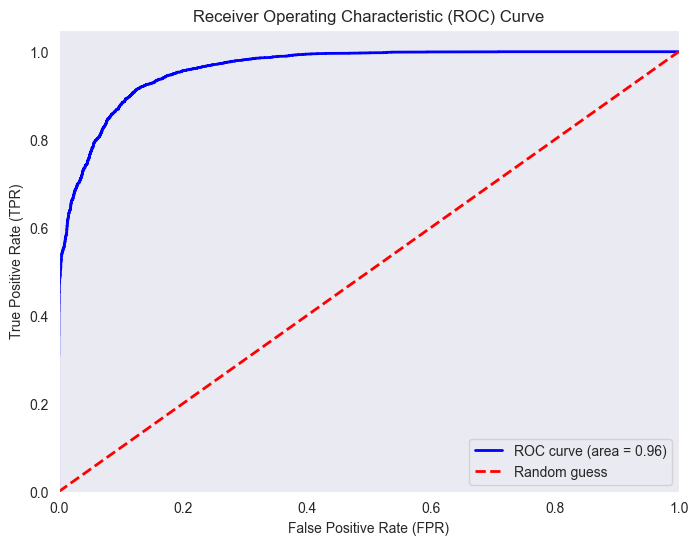

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Calculate the AUC
roc_auc = roc_auc_score(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

From the above graph, the AUC is 0.96, which is excellent. This high AUC value signifies that our model has a very high ability to distinguish between flats priced above and below the median. Specifically, an AUC of 0.96 means there is a 96% chance that our model will correctly classify a randomly chosen positive instance (above median price) as having a higher probability than a randomly chosen negative instance (below median price).

## Implementing K-Nearest Neighbors (KNN)

In [39]:
from sklearn.neighbors import KNeighborsClassifier

# Create the pipeline with a KNN classifier
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the preprocessor pipeline defined earlier
    ('classifier', KNeighborsClassifier(n_neighbors=5)) # You can choose the number of neighbors (k) as desired
])

# Fit the pipeline to the training data
knn_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = knn_pipeline.predict(X_val)
y_val_pred_proba = knn_pipeline.predict_proba(X_val)[:, 1]

In [40]:
# Calculate and print the classification metrics for the KNN model
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

print("K-Nearest Neighbors (KNN) Metrics:")
print(f'Validation Accuracy: {val_accuracy:.5f}')
print(f'Validation Precision: {val_precision:.5f}')
print(f'Validation Recall: {val_recall:.5f}')
print(f'Validation F1 Score: {val_f1:.5f}')
print(f'Validation ROC AUC: {val_roc_auc:.5f}')

K-Nearest Neighbors (KNN) Metrics:
Validation Accuracy: 0.87568
Validation Precision: 0.87995
Validation Recall: 0.86821
Validation F1 Score: 0.87404
Validation ROC AUC: 0.93997


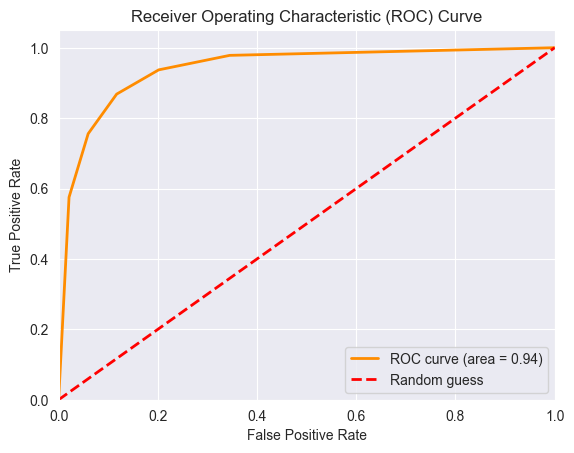

In [41]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_val, knn_pipeline.predict_proba(X_val)[:, 1])
roc_auc = roc_auc_score(y_val, knn_pipeline.predict_proba(X_val)[:, 1])

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Implementing Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the pipeline with a Decision Tree classifier
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(criterion='gini', min_samples_split=2, max_depth=None, random_state=42))
])

# Fit the pipeline to the training data
dt_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = dt_pipeline.predict(X_val)
y_val_pred_proba = dt_pipeline.predict_proba(X_val)[:, 1]

# Calculate metrics for the validation set
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

# Calculate metrics for the training set
y_train_pred = dt_pipeline.predict(X_train)
y_train_pred_proba = dt_pipeline.predict_proba(X_train)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)

print("Decision Tree Classifier Validation Metrics:")
print('-' * 40)
print('Validation Set Metrics:')
print(f'Validation Accuracy: {val_accuracy:.5f}')
print(f'Validation Precision: {val_precision:.5f}')
print(f'Validation Recall: {val_recall:.5f}')
print(f'Validation F1 Score: {val_f1:.5f}')
print(f'Validation ROC AUC: {val_roc_auc:.5f}')

print()
print("Training Set Metrics:")
print(f'Training Accuracy: {train_accuracy:.5f}')
print(f'Training Precision: {train_precision:.5f}')
print(f'Training Recall: {train_recall:.5f}')
print(f'Training F1 Score: {train_f1:.5f}')
print(f'Training ROC AUC: {train_roc_auc:.5f}')

Decision Tree Classifier Validation Metrics:
----------------------------------------
Validation Set Metrics:
Validation Accuracy: 0.89794
Validation Precision: 0.89672
Validation Recall: 0.89800
Validation F1 Score: 0.89736
Validation ROC AUC: 0.89962

Training Set Metrics:
Training Accuracy: 0.99617
Training Precision: 0.99934
Training Recall: 0.99294
Training F1 Score: 0.99613
Training ROC AUC: 0.99997


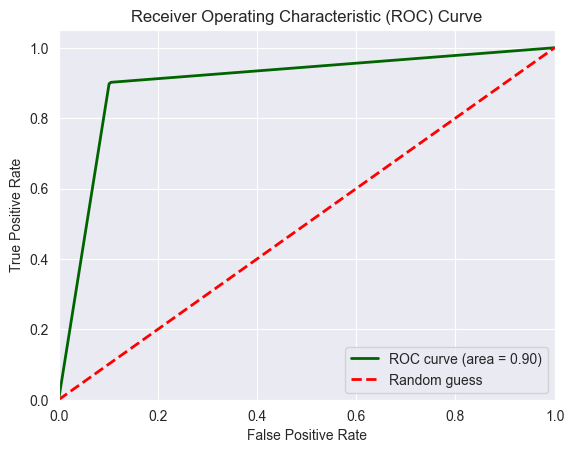

In [45]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)

plt.figure()
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The ROC curve is mostly positioned towards the top-left corner, indicating a good performance as it shows a high TPR and a low FPR across different thresholds. The ROC curve and AUC value of 0.90 for the Decision Tree classifier suggest that the model has a high ability to correctly classify the flats as Above Median or Below Median based on the features provided. However, it's important to balance this with the potential overfitting observed in the training metrics. Regularization techniques or tree pruning will be necessary to improve generalisability.

## Visualizing Decision Trees

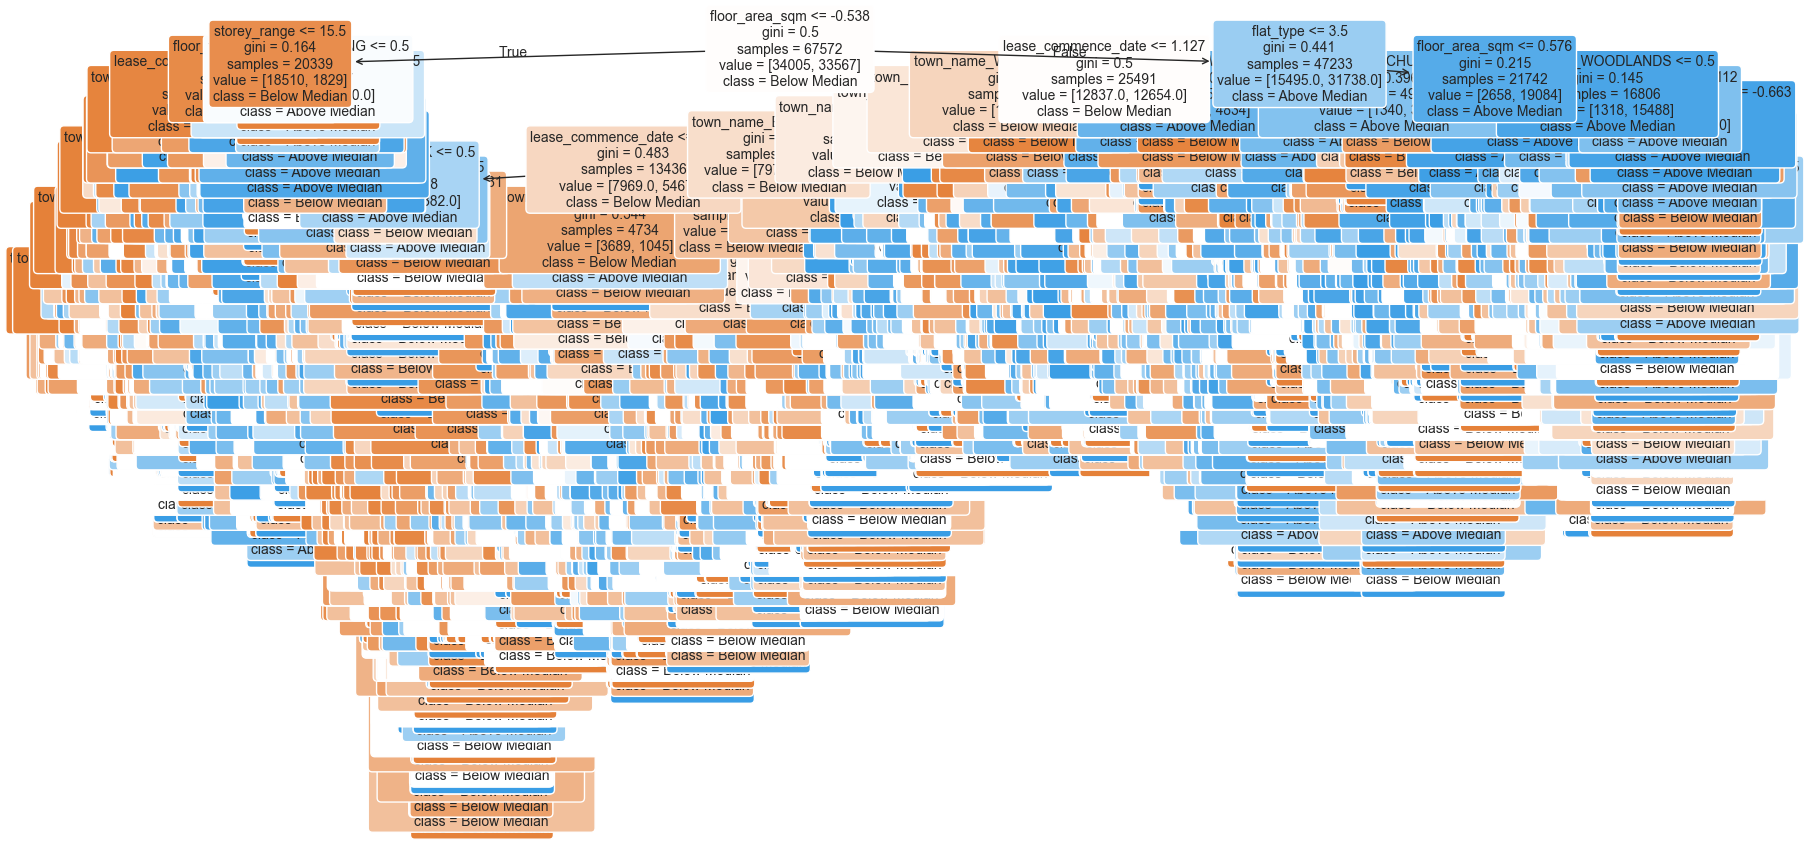

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extract the transformed feature names
feature_names = []
for name, transformer, columns in dt_pipeline.named_steps['preprocessor'].transformers_:
    if hasattr(transformer, 'named_steps'):
        for step in transformer.named_steps.values():
            if hasattr(step, 'get_feature_names_out'):
                feature_names.extend(step.get_feature_names_out(columns))
    elif hasattr(transformer, 'get_feature_names_out'):
        feature_names.extend(transformer.get_feature_names_out(columns))
    else:
        feature_names.extend(columns)
				
# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_pipeline.named_steps['classifier'], 
          feature_names=feature_names, 
          class_names=['Below Median', 'Above Median'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

## Pruning Decision Trees

In [48]:
# Create the new pipeline with a Decision Tree classifier with new max_depth pre-pruning parameter
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(criterion='gini', 
                                          min_samples_split=2, 
                                          max_depth=5, 
                                          min_samples_leaf=1, 
                                          random_state=42))
])
# Fit the new pipeline with pruning to the training data
# ...
# Fit the pipeline to the training data
dt_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = dt_pipeline.predict(X_val)


# Calculate metrics for the validation set
# ...



# Calculate metrics for the training set
# ...

# Predict on the validation set
y_val_pred = dt_pipeline.predict(X_val)
y_val_pred_proba = dt_pipeline.predict_proba(X_val)[:, 1]

# Calculate metrics for the validation set
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

# Calculate metrics for the training set
y_train_pred = dt_pipeline.predict(X_train)
y_train_pred_proba = dt_pipeline.predict_proba(X_train)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)

print("Decision Tree Classifier Validation Metrics:")
print('-' * 40)
print('Validation Set Metrics:')
print(f'Validation Accuracy: {val_accuracy:.5f}')
print(f'Validation Precision: {val_precision:.5f}')
print(f'Validation Recall: {val_recall:.5f}')
print(f'Validation F1 Score: {val_f1:.5f}')
print(f'Validation ROC AUC: {val_roc_auc:.5f}')

print()
print("Training Set Metrics:")
print(f'Training Accuracy: {train_accuracy:.5f}')
print(f'Training Precision: {train_precision:.5f}')
print(f'Training Recall: {train_recall:.5f}')
print(f'Training F1 Score: {train_f1:.5f}')
print(f'Training ROC AUC: {train_roc_auc:.5f}')

Decision Tree Classifier Validation Metrics:
----------------------------------------
Validation Set Metrics:
Validation Accuracy: 0.81660
Validation Precision: 0.88869
Validation Recall: 0.72116
Validation F1 Score: 0.79621
Validation ROC AUC: 0.91073

Training Set Metrics:
Training Accuracy: 0.81627
Training Precision: 0.89029
Training Recall: 0.71871
Training F1 Score: 0.79535
Training ROC AUC: 0.91136


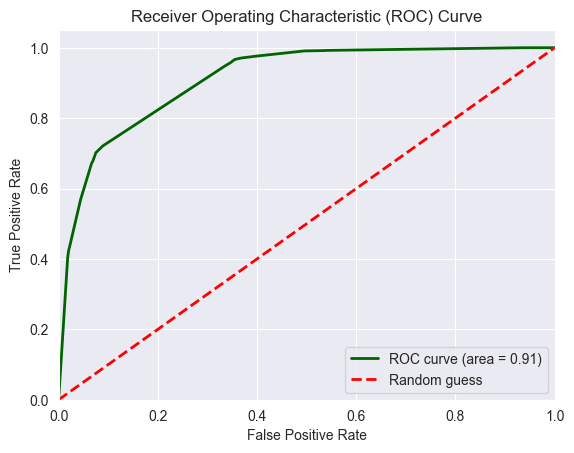

In [49]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)

plt.figure()
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Hyperparameter Tuning

### Implementing GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform grid search with cross-validation for Ridge regression
ridge_grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_grid_search.fit(X_train, y_train)

# Perform grid search with cross-validation for Lasso regression
lasso_grid_search = GridSearchCV(lasso_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid_search.fit(X_train, y_train)


### Implementing RandomSearchCV